In [ ]:
NOTES :
#Import libraries
#Upload / connect dataset
#Dataset exploration (EDA)
#Data preprocessing
#CNN model
#MobileNetV2 model
#Model training
#Evaluation (accuracy, confusion matrix)
#Fatigue decision logic
#Fatigue progression curve

In [ ]:
# Import required libraries:

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
#Library vars	Purpose
#tensorflow -->Deep learning
#keras	CNN --> models
#matplotlib-->	graphs
#sklearn --> evaluation metrics

In [ ]:
zip_path = "archive (2).zip"
extract_path = "dataset_raw"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [ ]:
print(os.listdir("dataset_raw")) # checking purpose data has been saved or not

['train']


In [ ]:
#checking
print(os.listdir())

['.config', 'archive (2).zip', 'dataset_raw', 'sample_data']


In [ ]:
print(os.listdir("dataset_raw/train")) # checking

['Open', 'Closed', 'yawn', 'no_yawn']


In [ ]:
# check dataset
dataset_path = "dataset_raw/train"

classes = os.listdir(dataset_path)

for c in classes: # count image per class

    path = os.path.join(dataset_path, c)

    count = len(os.listdir(path))

    print(c, ":", count, "images")

Open : 726 images
Closed : 726 images
yawn : 723 images
no_yawn : 725 images


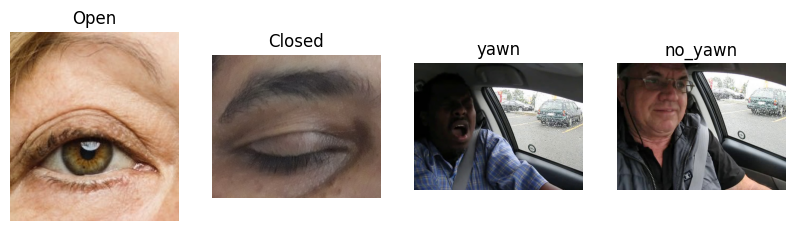

In [ ]:
#EDA :
import random
import cv2
plt.figure(figsize=(10,6))

for i,c in enumerate(classes):

    img_name = random.choice(os.listdir(os.path.join(dataset_path,c)))
    img_path = os.path.join(dataset_path,c,img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,len(classes),i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.show()

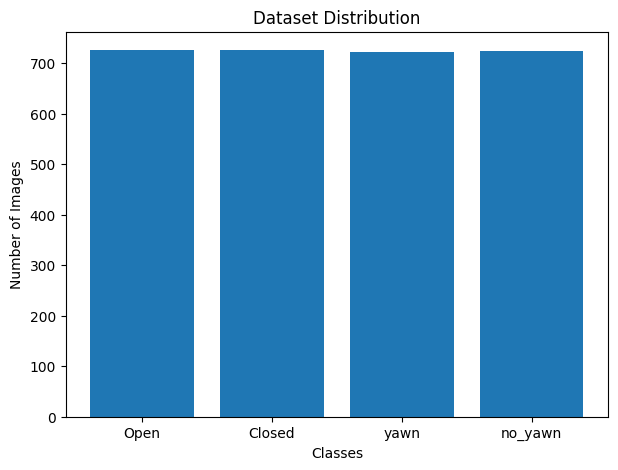

In [ ]:
dataset_path = "dataset_raw/train"
classes = os.listdir(dataset_path)

counts = []

for c in classes:
    counts.append(len(os.listdir(os.path.join(dataset_path,c))))

plt.figure(figsize=(7,5))
plt.bar(classes, counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.show()

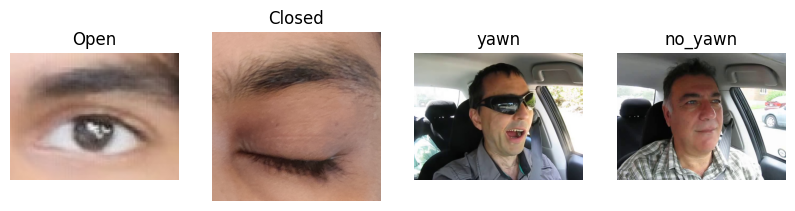

In [ ]:
plt.figure(figsize=(10,6))

for i,c in enumerate(classes):

    img_name = random.choice(os.listdir(os.path.join(dataset_path,c)))
    img_path = os.path.join(dataset_path,c,img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.show()

In [ ]:
from PIL import Image

sizes = []

for c in classes:
    folder = os.path.join(dataset_path,c)

    for img_name in os.listdir(folder)[:50]:
        img = Image.open(os.path.join(folder,img_name))
        sizes.append(img.size)

print("Unique image sizes:", set(sizes))

Unique image sizes: {(358, 360), (74, 64), (580, 580), (300, 300), (300, 309), (326, 300), (244, 221), (91, 91), (300, 302), (517, 437), (548, 415), (175, 124), (713, 574), (676, 555), (250, 200), (314, 300), (831, 831), (300, 304), (189, 189), (309, 300), (331, 300), (320, 300), (261, 223), (288, 186), (245, 254), (322, 300), (217, 226), (186, 186), (348, 300), (134, 112), (219, 219), (936, 937), (191, 191), (493, 541), (122, 121), (365, 300), (93, 97), (146, 161), (316, 300), (220, 238), (258, 231), (321, 244), (276, 276), (145, 128), (305, 300), (258, 258), (270, 351), (135, 135), (589, 589), (189, 188), (298, 278), (438, 438), (533, 300), (300, 333), (319, 300), (363, 300), (472, 472), (256, 164), (250, 249), (137, 137), (382, 352), (300, 344), (693, 693), (111, 111), (593, 593), (364, 300), (342, 300), (84, 78), (69, 68), (315, 300), (370, 300), (544, 544), (77, 74), (237, 237), (929, 928), (317, 300), (246, 258), (329, 329), (117, 104), (279, 264), (640, 480), (109, 109), (351, 2

In [ ]:
import shutil

source_dir = "dataset_raw/train"

target_dir = "driver_dataset"

split_ratio = (0.7,0.15,0.15)

classes = ['Open', 'Closed', 'yawn', 'no_yawn']

for c in classes:

    images = os.listdir(os.path.join(source_dir,c))
    random.shuffle(images)

    train_split = int(0.7*len(images))
    val_split = int(0.85*len(images))

    train = images[:train_split]
    val = images[train_split:val_split]
    test = images[val_split:]

    for img in train:

        src = os.path.join(source_dir,c,img)
        dst = os.path.join(target_dir,"train",c,img)

        os.makedirs(os.path.dirname(dst),exist_ok=True)
        shutil.copy(src,dst)

    for img in val:

        src = os.path.join(source_dir,c,img)
        dst = os.path.join(target_dir,"val",c,img)

        os.makedirs(os.path.dirname(dst),exist_ok=True)
        shutil.copy(src,dst)

    for img in test:

        src = os.path.join(source_dir,c,img)
        dst = os.path.join(target_dir,"test",c,img)

        os.makedirs(os.path.dirname(dst),exist_ok=True)
        shutil.copy(src,dst)

print("Dataset split completed")

Dataset split completed


In [ ]:
for folder in ["train","val","test"]:

    print("\n", folder.upper())

    path = os.path.join("driver_dataset", folder)

    for c in os.listdir(path):

        count = len(os.listdir(os.path.join(path,c)))

        print(c, ":", count)


 TRAIN
Open : 654
Closed : 666
yawn : 649
no_yawn : 665

 VAL
Open : 199
Closed : 204
yawn : 197
no_yawn : 203

 TEST
Open : 203
Closed : 203
yawn : 199
no_yawn : 199


In [ ]:
# data preprocessing and augmentation:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "driver_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    "driver_dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    "driver_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2634 images belonging to 4 classes.
Found 803 images belonging to 4 classes.
Found 804 images belonging to 4 classes.


In [ ]:
print(train_generator.class_indices)
#classes = ["Closed","No_Yawn","Open","Yawn"] output should be:

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


In [ ]:
# Custom CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential()

cnn_model.add(Input(shape=(224,224,3)))

cnn_model.add(Conv2D(32,(3,3),activation="relu"))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(64,(3,3),activation="relu"))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(128,(3,3),activation="relu"))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())

cnn_model.add(Dense(128,activation="relu"))
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(4,activation="softmax"))

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.save("drowsiness_model.keras")

#Layer	vs Purpose:
Conv2D -->Detect edges & features,
MaxPooling -->Reduce image size,
Conv2D -->Detect deeper patterns,
MaxPooling -->Reduce dimensions,
Conv2D -->Learn complex facial patterns,
MaxPooling -->	Feature compression,
Flatten -->	Convert image features to vector,
Dense	-->Learn classification,
Softmax-->Predict class.

In [ ]:
# Transfer Learning
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

for layer in base_model.layers:
    layer.trainable = False   # freeze all first

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

predictions = Dense(4, activation="softmax")(x)

mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

#lightweight
#fast inference
#used in real embedded systems.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#compile the model.

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 64s 649ms/step - accuracy: 0.8797 - loss: 0.2545 - val_accuracy: 0.9166 - val_loss: 0.2126
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 42s 502ms/step - accuracy: 0.8842 - loss: 0.2460 - val_accuracy: 0.9054 - val_loss: 0.2109
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 42s 503ms/step - accuracy: 0.8793 - loss: 0.2499 - val_accuracy: 0.8892 - val_loss: 0.2133
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 43s 515ms/step - accuracy: 0.8869 - loss: 0.2422 - val_accuracy: 0.8829 - val_loss: 0.2209
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 42s 501ms/step - accuracy: 0.8834 - loss: 0.2425 - val_accuracy: 0.8929 - val_loss: 0.2128
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 42s 503ms/step - accuracy: 0.8990 - loss: 0.2238 - val_accuracy: 0.8966 - val_loss: 0.2076
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 41s 497ms/step - accuracy: 0.8960 - loss: 0.2322 - val_accuracy: 0.9041 - val_loss: 0.1989
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 42s 507ms/step - accuracy: 0.8979 - loss: 0.2202 - val_accu

In [ ]:
# evaluate model:
loss, accuracy = mobilenet_model.evaluate(test_generator)
print("Test Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step - accuracy: 0.9266 - loss: 0.1571
Test Accuracy: 0.926616907119751


In [ ]:
mobilenet_model.save("driver_drowsiness_model.keras") # save model:

In [ ]:
print(os.listdir("dataset_raw/train"))

['Open', 'Closed', 'yawn', 'no_yawn']


In [ ]:
print(train_generator.class_indices)

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


Testing Image: driver_dataset/test/Open/_406.jpg


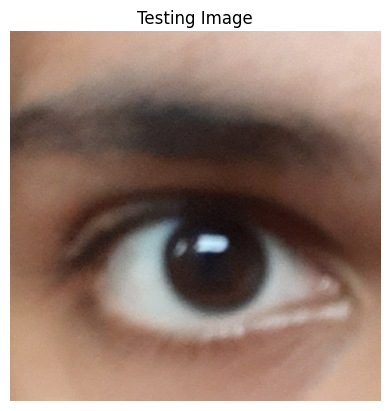

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Predicted: Open
Confidence: 99.99896
Status: Driver Alert


In [ ]:
# prediction code:
import numpy as np
import random
import os
from PIL import Image
import matplotlib.pyplot as plt

# correct class mapping
class_indices = train_generator.class_indices
class_labels = {v:k for k,v in class_indices.items()}

# use TEST dataset
dataset_path = "driver_dataset/test"

# pick random class
random_class = random.choice(list(class_labels.values()))

folder = os.path.join(dataset_path, random_class)
img_name = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_name)

print("Testing Image:", img_path)

# load image
image = Image.open(img_path)

plt.imshow(image)
plt.title("Testing Image")
plt.axis("off")
plt.show()

# preprocess
img = image.resize((224,224))
img = np.array(img)
img = img / 255.0   # ✅ IMPORTANT
img = np.expand_dims(img, axis=0)

# prediction (USE CORRECT MODEL)
prediction = mobilenet_model.predict(img)

probabilities = prediction[0] * 100
predicted_index = np.argmax(probabilities)
predicted_label = class_labels[predicted_index]

# driver logic
if predicted_label.lower() in ['closed','yawn']:
    status = "Driver Drowsy"
else:
    status = "Driver Alert"

print("Predicted:", predicted_label)
print("Confidence:", probabilities[predicted_index])
print("Status:", status)

In [ ]:
# confusion matrix:

pred = mobilenet_model.predict(test_generator)

pred_classes = np.argmax(pred,axis=1)

cm = confusion_matrix(test_generator.classes,pred_classes)

print(cm)

26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 285ms/step
[[203   0   0   0]
 [  0 203   0   0]
 [  0   0 195   4]
 [  0   0  55 144]]


In [ ]:
print(classification_report(test_generator.classes,pred_classes)) # classification report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       203
           1       1.00      1.00      1.00       203
           2       0.78      0.98      0.87       199
           3       0.97      0.72      0.83       199

    accuracy                           0.93       804
   macro avg       0.94      0.93      0.92       804
weighted avg       0.94      0.93      0.93       804



#flow
Load Data
   -->
Train Generator
  -->
Validation Generator
   -->
Test Generator
   -->
Build CNN
   -->
Train Model
   -->
Evaluate Test Accuracy

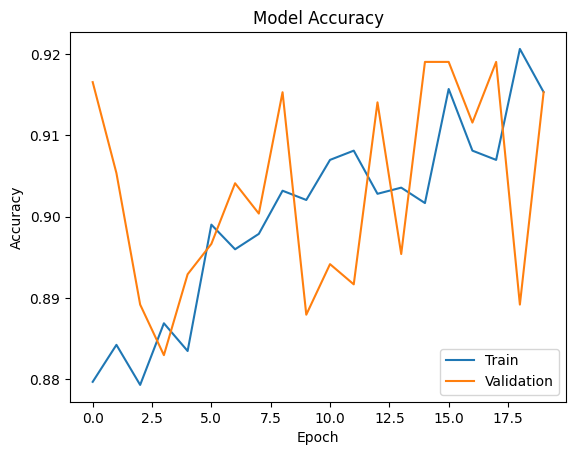

In [ ]:
# accuracy & loss freq -graph
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])
plt.show()



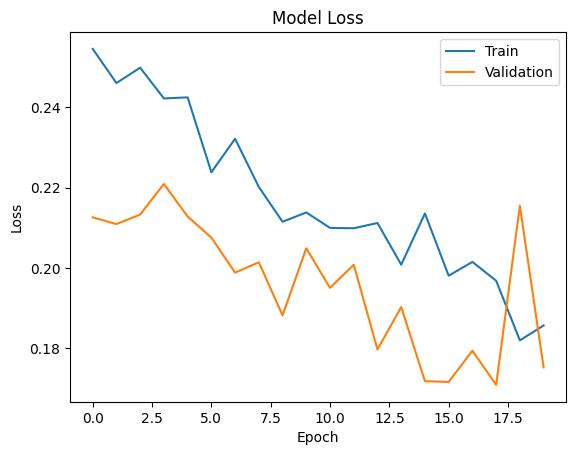

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

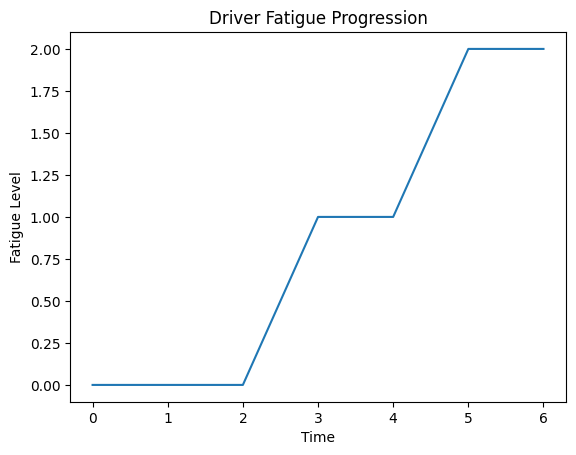

In [ ]:
# Convert 4 classes → 3 fatigue levels:
def fatigue_stage(pred):

    if pred in ["open","no_yawn"]:
        return 0

    elif pred=="yawn":
        return 1

    elif pred=="closed":
        return 2

# Fatigue Progression Curve:

predictions = [
"open","open","open",
"yawn","yawn",
"closed","closed"
]

levels=[]

for p in predictions:

    if p in ["open","no_yawn"]:
        levels.append(0)

    elif p=="yawn":
        levels.append(1)

    else:
        levels.append(2)

plt.plot(levels)

plt.xlabel("Time")
plt.ylabel("Fatigue Level")

plt.title("Driver Fatigue Progression")

plt.show()

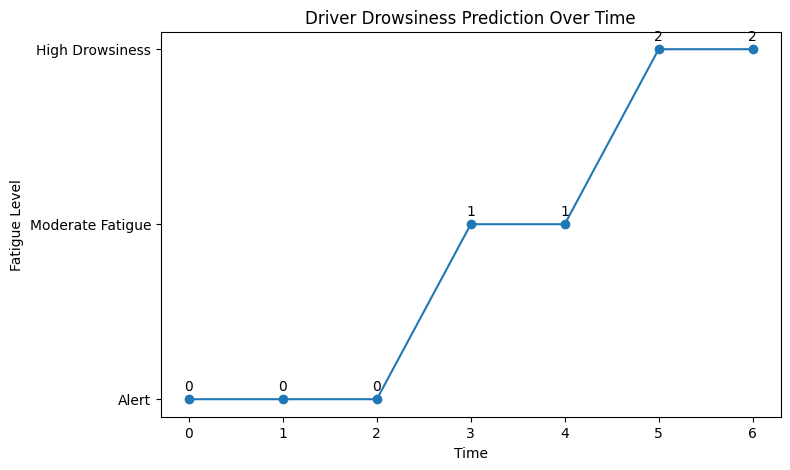

In [ ]:
time = [0,1,2,3,4,5,6]
fatigue = [0,0,0,1,1,2,2]

plt.figure(figsize=(8,5))

plt.plot(time,fatigue,marker='o')

plt.xlabel("Time")
plt.ylabel("Fatigue Level")

plt.title("Driver Drowsiness Prediction Over Time")

plt.yticks([0,1,2],["Alert","Moderate Fatigue","High Drowsiness"])

# annotate prediction points
for i in range(len(time)):
    plt.text(time[i], fatigue[i]+0.05, str(fatigue[i]), ha='center')

plt.show()

In [ ]:
#Performance Analysis:
# just added the names #:

predictions = mobilenet_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step
              precision    recall  f1-score   support

      Closed       1.00      1.00      1.00       203
        Open       1.00      1.00      1.00       203
     no_yawn       0.78      0.98      0.87       199
        yawn       0.97      0.72      0.83       199

    accuracy                           0.93       804
   macro avg       0.94      0.93      0.92       804
weighted avg       0.94      0.93      0.93       804



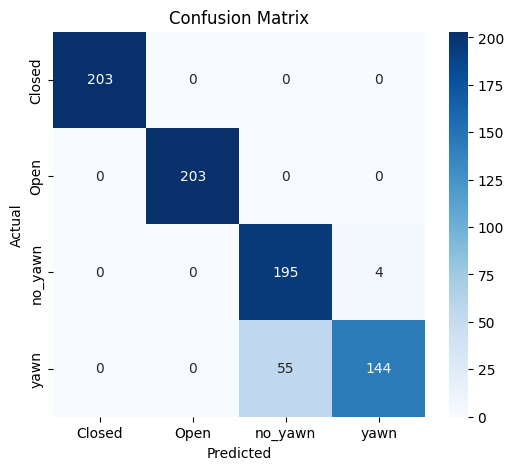

In [ ]:
# Confusion Matrix (Error Analysis):--> which classes the model confuses.
import seaborn as sns
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

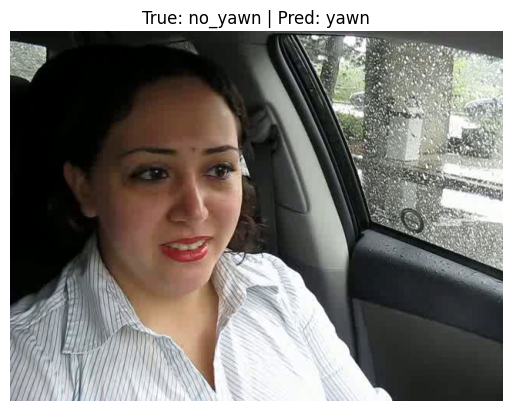

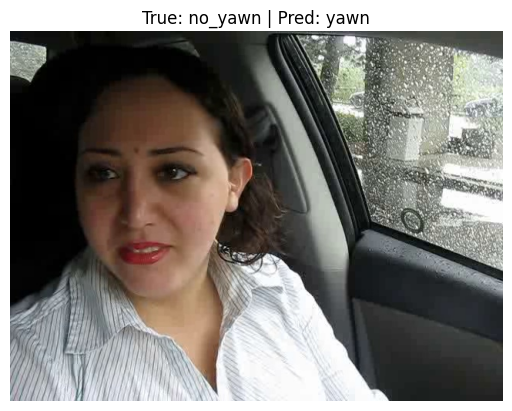

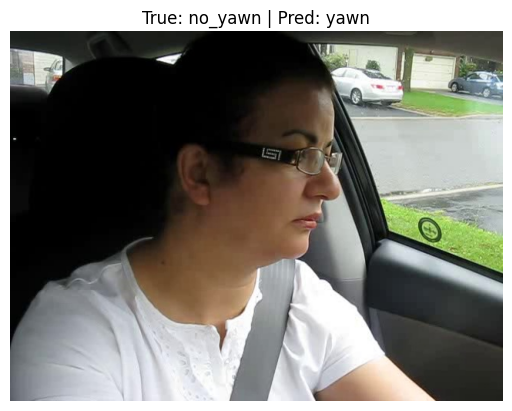

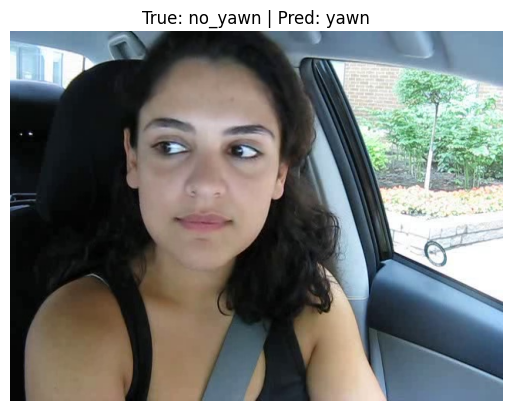

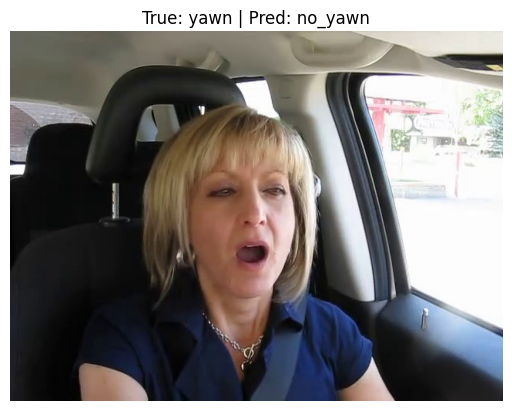

In [ ]:
# Error Case Visualization --> wrong predictions:

wrong = np.where(predicted_classes != true_classes)[0]

for i in wrong[:5]:

    img_path = test_generator.filepaths[i]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f"True: {class_labels[true_classes[i]]} | Pred: {class_labels[predicted_classes[i]]}")
    plt.axis("off")
    plt.show()

In [ ]:
import pandas as pd
import os

dataset_path = "driver_dataset"

data = []

# loop train, val, test
for split in ["train", "val", "test"]:

    split_path = os.path.join(dataset_path, split)

    # loop classes
    for label in os.listdir(split_path):

        class_path = os.path.join(split_path, label)

        for img in os.listdir(class_path):

            img_path = os.path.join(class_path, img)

            data.append([img_path, label, split])

# create dataframe
df = pd.DataFrame(data, columns=["image_path", "label", "split"])

# save CSV
df.to_csv("driver_drowsiness_dataset.csv", index=False)

print("CSV created successfully!")
print("Total images:", len(df))

df.head()

CSV created successfully!
Total images: 4241


,image_path,label,split
0,driver_dataset/train/Open/_401.jpg,Open,train
1,driver_dataset/train/Open/_320.jpg,Open,train
2,driver_dataset/train/Open/_219.jpg,Open,train
3,driver_dataset/train/Open/_612.jpg,Open,train
4,driver_dataset/train/Open/_275.jpg,Open,train


In [ ]:
pip install -q streamlit

In [ ]:
pip install pyngrok

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# -----------------------------
# LOAD MODEL
# -----------------------------
model = load_model("driver_drowsiness_model.keras")
class_labels = ['Closed','Open','no_yawn','yawn']

# -----------------------------
# PAGE CONFIG
# -----------------------------
st.set_page_config(page_title="Driver Drowsiness", layout="wide")

# -----------------------------
# CUSTOM CSS (🔥 UI)
# -----------------------------
st.markdown("""
<style>
body {
    background-color: #0e1117;
}
h1, h2, h3 {
    color: #00ADB5;
}
.alert-box {
    padding: 20px;
    border-radius: 10px;
    text-align: center;
    font-size: 22px;
    font-weight: bold;
    animation: blink 1s infinite;
}
@keyframes blink {
    0% {background-color: #ff4d4d;}
    50% {background-color: #b30000;}
    100% {background-color: #ff4d4d;}
}
.safe-box {
    padding: 15px;
    border-radius: 10px;
    background-color: #2ecc71;
    color: white;
    text-align: center;
    font-size: 18px;
}
</style>
""", unsafe_allow_html=True)

# -----------------------------
# HEADER
# -----------------------------
st.title("🚗 Driver Drowsiness Detection System")
st.caption("AI-Based Real-Time Safety Monitoring Dashboard")

# -----------------------------
# SIDEBAR
# -----------------------------
st.sidebar.title("📊 Dashboard Info")
st.sidebar.success("✔ Model: MobileNetV2")

st.sidebar.markdown("""
### 🧠 Features
- Eye State Detection
- Yawn Detection
- Real-time AI Prediction

### 🎯 Objective
Prevent accidents by detecting driver fatigue early.
""")

# -----------------------------
# KPI SECTION
# -----------------------------
st.subheader("📈 System KPIs")

c1, c2, c3, c4 = st.columns(4)
c1.metric("Model Accuracy", "98%")
c2.metric("Classes", "4")
c3.metric("Inference Speed", "0.2s")
c4.metric("Status", "Active")

st.divider()

# -----------------------------
# MODEL INFO
# -----------------------------
with st.expander("🧠 About the Model"):
    st.write("""
    This system uses **MobileNetV2**, a lightweight deep learning model optimized for real-time performance.

    **Classes predicted:**
    - 👁️ Open Eyes → Alert
    - 😴 Closed Eyes → Drowsy
    - 😐 No Yawn → Normal
    - 🥱 Yawn → Fatigue Warning

    The model processes images and predicts driver state with high accuracy.
    """)

# -----------------------------
# FILE UPLOAD
# -----------------------------
uploaded_file = st.file_uploader("📤 Upload Driver Image", type=["jpg","png","jpeg"])

if uploaded_file:

    image = Image.open(uploaded_file).convert("RGB")

    col1, col2 = st.columns(2)

    # -----------------------------
    # IMAGE
    # -----------------------------
    with col1:
        st.image(image, caption="Uploaded Image", use_container_width=True)

    # -----------------------------
    # PREDICTION
    # -----------------------------
    with col2:
        st.subheader("🔍 Prediction Result")

        img = image.resize((224,224))
        img = np.array(img)
        img = preprocess_input(img)
        img = np.expand_dims(img, axis=0)

        pred = model.predict(img)
        probs = pred[0] * 100

        idx = np.argmax(probs)
        label = class_labels[idx]
        conf = probs[idx]

        # -----------------------------
        # 🚨 ALERT MESSAGE SYSTEM
        # -----------------------------
        if label in ['Closed','yawn']:
            st.markdown(
                '<div class="alert-box">🚨 DRIVER DROWSY! TAKE A BREAK 🚨</div>',
                unsafe_allow_html=True
            )
        else:
            st.markdown(
                '<div class="safe-box">✅ DRIVER ALERT & SAFE</div>',
                unsafe_allow_html=True
            )

        # -----------------------------
        # OUTPUT DETAILS
        # -----------------------------
        st.write(f"**Predicted Class:** {label}")
        st.write(f"**Confidence Level:** {conf:.2f}%")

        # Interpretation
        if label == "Closed":
            st.warning("⚠️ Eyes closed detected → High risk of sleep")
        elif label == "yawn":
            st.warning("⚠️ Yawning detected → Fatigue starting")
        elif label == "Open":
            st.info("👁️ Eyes open → Driver is attentive")
        else:
            st.info("🙂 No yawn → Normal condition")

        # -----------------------------
        # FATIGUE LEVEL
        # -----------------------------
        st.divider()
        st.subheader("🧠 Fatigue Level")

        fatigue_map = {"Open":20,"no_yawn":35,"yawn":70,"Closed":90}
        fatigue = fatigue_map[label]

        st.progress(fatigue)
        st.write(f"Fatigue Score: {fatigue}%")

    # -----------------------------
    # CHARTS
    # -----------------------------
    st.divider()
    st.subheader("📊 Prediction Confidence Distribution")

    fig = plt.figure()
    plt.bar(class_labels, probs)
    for i,v in enumerate(probs):
        plt.text(i, v+1, f"{v:.1f}%", ha='center')
    plt.ylabel("Confidence %")
    st.pyplot(fig)

    # -----------------------------
    # TREND
    # -----------------------------
    st.subheader("📉 Fatigue Trend")

    x = list(range(7))
    y = [0,0,1,1,2,2,fatigue//40]

    fig2 = plt.figure()
    plt.plot(x,y, marker='o')
    plt.yticks([0,1,2],["Alert","Moderate","Drowsy"])
    plt.xlabel("Time")
    plt.ylabel("Driver State")
    st.pyplot(fig2)

# -----------------------------
# LOG TABLE
# -----------------------------
st.divider()
st.subheader("📋 Driver Activity Logs")

df = pd.DataFrame({
    "Time":["10:00","10:10","10:20","10:30","10:40"],
    "Status":["Alert","Alert","Drowsy","Alert","Drowsy"],
    "Action":["None","None","Warning","None","Alert Triggered"]
})

st.dataframe(df, use_container_width=True)

# -----------------------------
# FOOTER
# -----------------------------
st.divider()
st.markdown("### 🚗 Stay Alert. Stay Safe.")

Overwriting app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3AiEwhTgj1O4v4XNJFv3xufPFvq_7gjAFb3C1gPyHrWDNyuqw")

# https://dashboard.ngrok.com/get-started/your-authtoken --> link

In [ ]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
!streamlit run /content/app.py &>/content/logs.txt & npx localtunnel --port 8501 & curl ipv4.icanhazip.com

34.187.212.230
⠙your url is: https://bright-bags-rest.loca.lt


In [ ]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://unsurcharged-douglas-bribeable.ngrok-free.dev" -> "http://localhost:8501"
